<a href="https://colab.research.google.com/github/Psyche-1/goit-ds-hw/blob/main/Hw2.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import pandas as pd
from io import StringIO
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
url = 'https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8'
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}
response = requests.get(url, headers=headers)
tmp = pd.read_html(StringIO(response.text), attrs={"class": "wikitable collapsible collapsed"}, decimal=',', thousands=None)
df = tmp[3]
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


Вивести перші рядки таблиці за допомогою методу head

In [ ]:
df.head()

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—


Визначте кількість рядків та стовпців у датафреймі (атрибут shape)

In [ ]:
df.shape

(28, 9)

Замініть у таблиці значення "—" на значення NaN

In [ ]:
df.replace('—', np.nan, inplace=True)
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


Визначте типи всіх стовпців за допомогою dataframe.dtypes

In [ ]:
df.dtypes

,0
Регіон,object
1950,float64
1960,float64
1970,float64
1990,float64
2000,float64
2012,float64
2014,object
2019,object


Замініть типи нечислових колонок на числові. Підказка - це колонки, де знаходився символ "—"

In [ ]:
cols = df.columns[1:]
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [ ]:
df.dtypes

,0
Регіон,object
1950,float64
1960,float64
1970,float64
1990,float64
2000,float64
2012,float64
2014,float64
2019,float64


Порахуйте, яка частка пропусків міститься в кожній колонці (використовуйте методи isnull та sum)

In [ ]:
df.isnull().sum()

,0
Регіон,0
1950,2
1960,1
1970,1
1990,0
2000,0
2012,0
2014,2
2019,4


Видаліть з таблиці дані по всій країні, останній рядок таблиці

In [ ]:
df = df[:-1]

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


In [ ]:
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,NaN,NaN
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,NaN
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


Замініть відсутні дані в стовпцях середніми значеннями цих стовпців (метод fillna)

In [ ]:
cols = df.columns[1:]
df.loc[:, cols] = df[cols].fillna(df[cols].mean())
df = df.round(1)
df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,11.1,8.0
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,8.0
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


Отримайте список регіонів, де рівень народжуваності у 2019 році був вищим за середній по Україні

In [ ]:
mean_2019 = df['2019'].mean()
regions_above_mean = df[df['2019'] > mean_2019][[df.columns[0], '2019']]
regions_above_mean


,Регіон,2019
2,Волинська,10.1
6,Закарпатська,10.4
8,Івано-Франківська,8.8
12,Львівська,8.7
14,Одеська,8.8
16,Рівненська,10.7
20,Херсонська,8.1
23,Чернівецька,9.2
25,Київ,11.0


У якому регіоні була найвища народжуваність у 2014 році?

In [ ]:
top_region = df.loc[df['2014'].idxmax()]
top_region.iloc[0]

'Рівненська'

Побудуйте стовпчикову діаграму народжуваності по регіонах у 2019 році

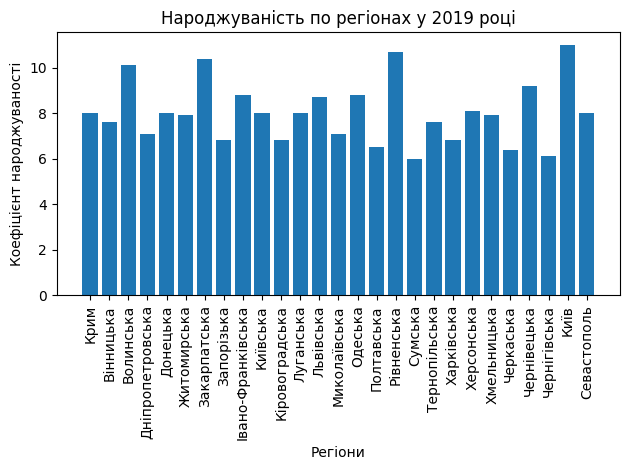

In [ ]:
regions = df.iloc[:, 0]
values_2019 = df['2019']
plt.bar(regions, values_2019)

plt.xlabel('Регіони')
plt.ylabel('Коефіцієнт народжуваності')
plt.title('Народжуваність по регіонах у 2019 році')

plt.xticks(rotation=90)

plt.show()

Додайте від 3 до 5 графіків функцій різного типу на ваш вибір. Задайте графікам оформлення, щоб кожен графік у своїй домашній роботі чимось відрізнявся і не був схожим на інші. Можна використовувати як matplotlib, так і seaborn.

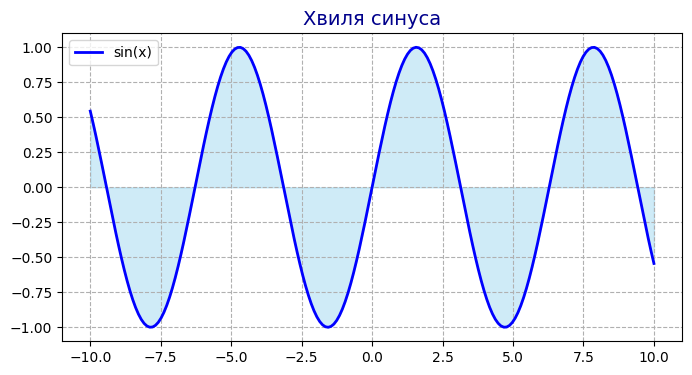

In [ ]:
x = np.linspace(-10, 10, 200)

plt.figure(figsize=(8, 4))
plt.fill_between(x, np.sin(x), color="skyblue", alpha=0.4)
plt.plot(x, np.sin(x), color="blue", lw=2, label='sin(x)')
plt.title("Хвиля синуса", fontsize=14, color='darkblue')
plt.grid(True, ls='--')
plt.legend()
plt.show()

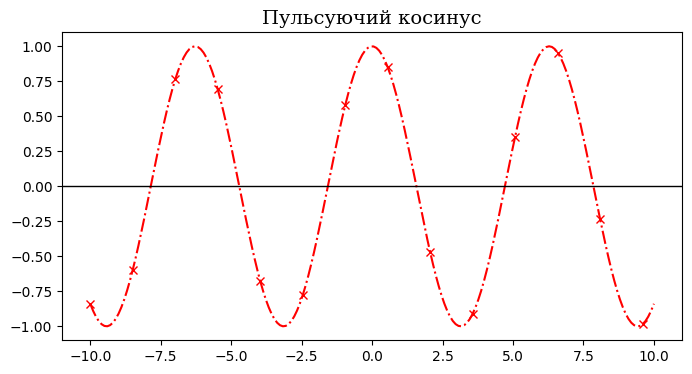

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(x, np.cos(x), color="red", ls='-.', marker='x', markevery=15)
plt.title("Пульсуючий косинус", fontsize=14, fontfamily='serif')
plt.axhline(0, color='black', lw=1)
plt.show()

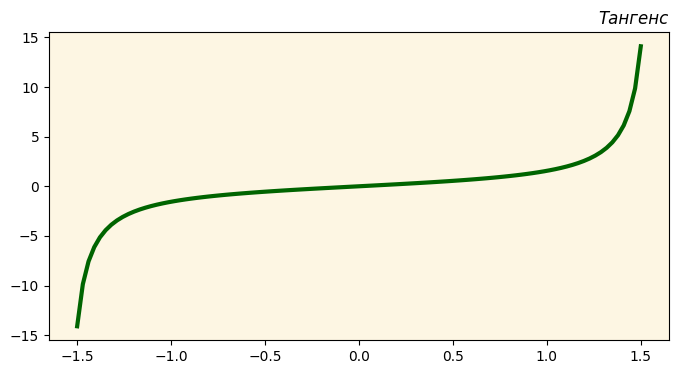

In [ ]:
plt.figure(figsize=(8, 4))
x_tan = np.linspace(-1.5, 1.5, 100)
plt.plot(x_tan, np.tan(x_tan), color="darkgreen", lw=3)
plt.title("Тангенс", loc='right', style='italic')
plt.gca().set_facecolor('#fdf6e3')
plt.show()